# 03 — Exponential Indifference Model

### Objective

This notebook implements the Exponential Indifference Model for reaction time.

The model assumes that reaction time depends on the absolute difference in
subjective value between the immediate and delayed options.

The model is fitted on the training data using a likelihood-based approach
with a Gaussian RT noise model and evaluated on held-out test data.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/aarohi_verma/Downloads/final_project/ICCS2026_Final_Project


### 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from src.config import DATA_DIR
from src.data_loader import load_all_participants
from src.preprocessing import get_split, combine_participants
from src.discounting import add_subjective_values

from src.rt_models import (
    predict_rt_exponential,
    fit_rt_model_exponential,
    add_predicted_rt_exponential
)

### 2. Load and Prepare Data

In [3]:
participants = load_all_participants(DATA_DIR)

In [4]:
train = get_split(participants, "train")
test = get_split(participants, "test")

combined_train = combine_participants(train)
combined_test = combine_participants(test)

print("Train:", combined_train.shape)
print("Test:", combined_test.shape)

Train: (8920, 8)
Test: (20070, 8)


In [5]:
combined_train = add_subjective_values(
    combined_train,
    k=0.01
)

combined_test = add_subjective_values(
    combined_test,
    k=0.01
)

print("Training columns:")
print(combined_train.columns.tolist())

print("\nTest columns:")
print(combined_test.columns.tolist())

Training columns:
['immOutcome', 'delOutcome', 'delay', 'choice', 'p_imm', 'condition', 'RT', 'participant', 'SV_immediate', 'SV_delayed', 'value_difference']

Test columns:
['immOutcome', 'delOutcome', 'delay', 'choice', 'p_imm', 'condition', 'RT', 'participant', 'SV_immediate', 'SV_delayed', 'value_difference']


### 3. Data Quality Check

Before fitting the model, we check for missing values in reaction time and subjective value difference.

In [6]:
print("Missing values in training data:")
print(
    combined_train[["RT", "value_difference"]]
    .isnull()
    .sum()
)

print("\nMissing values in test data:")
print(
    combined_test[["RT", "value_difference"]]
    .isnull()
    .sum()
)

Missing values in training data:
RT                  34
value_difference     0
dtype: int64

Missing values in test data:
RT                  59
value_difference    60
dtype: int64


### 4. Reaction Time Exploration

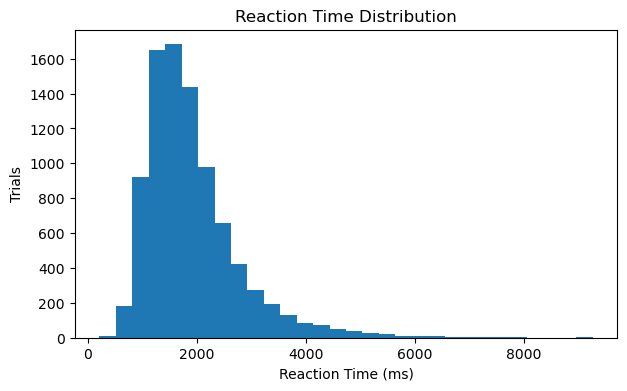

In [7]:
plt.figure(figsize=(7, 4))

plt.hist(
    combined_train["RT"].dropna(),
    bins=30
)

plt.xlabel("Reaction Time (ms)")
plt.ylabel("Trials")
plt.title("Reaction Time Distribution")

plt.show()

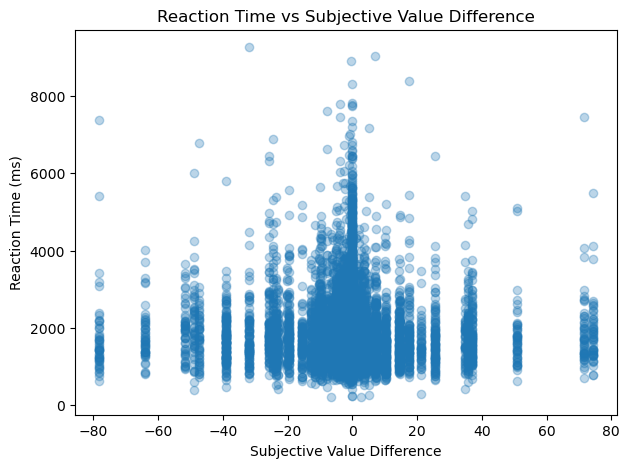

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(
    combined_train["value_difference"],
    combined_train["RT"],
    alpha=0.3
)

plt.xlabel("Subjective Value Difference")
plt.ylabel("Reaction Time (ms)")
plt.title("Reaction Time vs Subjective Value Difference")

plt.show()

## 5. Exponential Indifference Model

The Exponential Indifference Model assumes that reaction times decrease as
the absolute difference in subjective value increases.

The expected reaction time is defined as:

\[
\mu_i =
a + b\exp(-c|\Delta SV_i|)
\]

where \(a\) is the baseline reaction time, \(b\) controls the magnitude of
the effect, and \(c\) controls how quickly the effect decreases with
increasing subjective-value difference.

We assume Gaussian residual variability:

\[
RT_i \sim \mathcal{N}(\mu_i,\sigma^2)
\]

where \(\sigma\) represents residual reaction-time variability.

In [9]:
def predict_rt_exponential(value_difference, a, b, c):
    return (a + b * np.exp(-c * np.abs(value_difference)))

In [10]:
def rt_negative_log_likelihood(params, df):
    a, b, c, sigma = params

    if sigma <= 0:
        return np.inf

    predicted = predict_rt_exponential(df["value_difference"].to_numpy(), a, b, c)
    observed = df["RT"].to_numpy()
    residuals = observed - predicted

    nll = (0.5 * np.log(2 * np.pi * sigma**2) + (residuals**2) / (2 * sigma**2))

    return np.mean(nll)

In [11]:
def fit_exponential_rt_model(df):
    df = df.dropna(
        subset=["RT", "value_difference"]
    ).copy()

    result = minimize(
        rt_negative_log_likelihood,
        x0=[
            1000,
            1000,
            0.01,
            500
        ],
        args=(df,),
        bounds=[
            (100, 5000),
            (0.001, 10000),
            (0.000001, 20),
            (1, 5000)
        ],
        method="L-BFGS-B"
    )

    return result

In [12]:
train_model_data = combined_train.dropna(
    subset=[
        "RT",
        "value_difference"]).copy()

print("Training observations used:", len(train_model_data))

Training observations used: 8886


In [13]:
result = fit_exponential_rt_model(train_model_data)

print("Optimization successful:", result.success)

print("Message:", result.message)

Optimization successful: True
Message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


In [14]:
exp_a, exp_b, exp_c, exp_sigma = result.x

print(f"a     = {exp_a:.4f}")
print(f"b     = {exp_b:.4f}")
print(f"c     = {exp_c:.6f}")
print(f"sigma = {exp_sigma:.4f} ms")

a     = 990.2069
b     = 989.6605
c     = 0.005438
sigma = 894.0053 ms


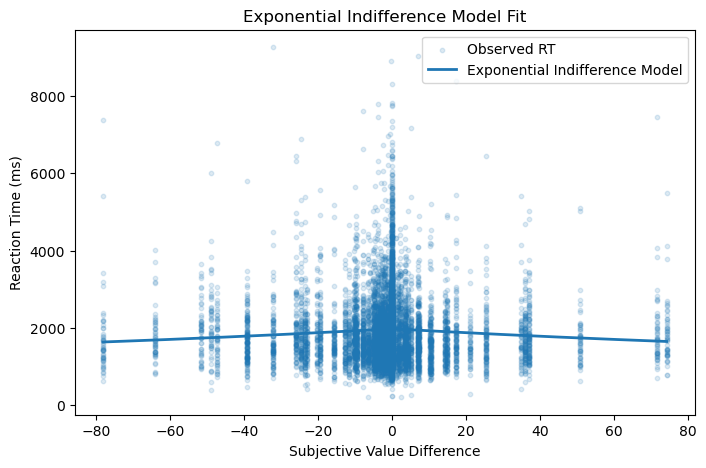

In [15]:
x = np.linspace(
    train_model_data["value_difference"].min(),
    train_model_data["value_difference"].max(),
    300)

y = predict_rt_exponential(x, exp_a, exp_b, exp_c)

plt.figure(figsize=(8, 5))

plt.scatter(
    train_model_data["value_difference"],
    train_model_data["RT"],
    alpha=0.15,
    s=10,
    label="Observed RT")

plt.plot(
    x,
    y,
    linewidth=2,
    label="Exponential Indifference Model")

plt.xlabel("Subjective Value Difference")
plt.ylabel("Reaction Time (ms)")
plt.title("Exponential Indifference Model Fit")
plt.legend()

plt.show()

## 6. Out-of-Sample Prediction

In [16]:
test_pred = combined_test.copy()

test_pred["predicted_RT"] = predict_rt_exponential(test_pred["value_difference"], exp_a, exp_b, exp_c)

test_pred[["RT", "value_difference", "predicted_RT"]].head()

,RT,value_difference,predicted_RT
0,1507.5,-0.608925,1976.595950
1,1260.5,3.045789,1963.611874
2,2113.5,7.976316,1937.861494
3,1764.1,1.957143,1969.391132
4,1984.3,-0.795385,1975.596366


In [17]:
evaluation = test_pred.dropna(
    subset=[
        "RT",
        "predicted_RT"]).copy()

print("Test observations before evaluation:",len(test_pred))

print("Test observations used for evaluation:",len(evaluation))

Test observations before evaluation: 20070
Test observations used for evaluation: 19952


In [18]:
y_true = evaluation["RT"]
y_pred = evaluation["predicted_RT"]

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

r2 = r2_score(y_true, y_pred)

print(f"MAE:  {mae:.2f} ms")
print(f"RMSE: {rmse:.2f} ms")
print(f"R²:   {r2:.4f}")

MAE:  719.70 ms
RMSE: 946.12 ms
R²:   -0.0527


In [19]:
baseline_mean = train_model_data["RT"].mean()

baseline_pred = np.full(len(evaluation), baseline_mean)

baseline_mae = mean_absolute_error(y_true, baseline_pred)

baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_pred))

baseline_r2 = r2_score(y_true, baseline_pred)

print(f"Mean RT baseline: {baseline_mean:.2f} ms")
print(f"Baseline MAE:     {baseline_mae:.2f} ms")
print(f"Baseline RMSE:    {baseline_rmse:.2f} ms")
print(f"Baseline R²:      {baseline_r2:.4f}")

Mean RT baseline: 1913.05 ms
Baseline MAE:     714.47 ms
Baseline RMSE:    944.67 ms
Baseline R²:      -0.0495


In [20]:
results = pd.DataFrame({
    "Model": ["Mean RT Baseline", "Exponential Indifference Model"],
    "MAE": [baseline_mae, mae],
    "RMSE": [baseline_rmse, rmse],
    "R2": [baseline_r2, r2]})

results

,Model,MAE,RMSE,R2
0,Mean RT Baseline,714.465627,944.669615,-0.049470
1,Exponential Indifference Model,719.695222,946.115319,-0.052684


In [21]:
mae_improvement = (
    (baseline_mae - mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rmse) / baseline_rmse
) * 100

print(f"MAE improvement:  {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement:  -0.73%
RMSE improvement: -0.15%


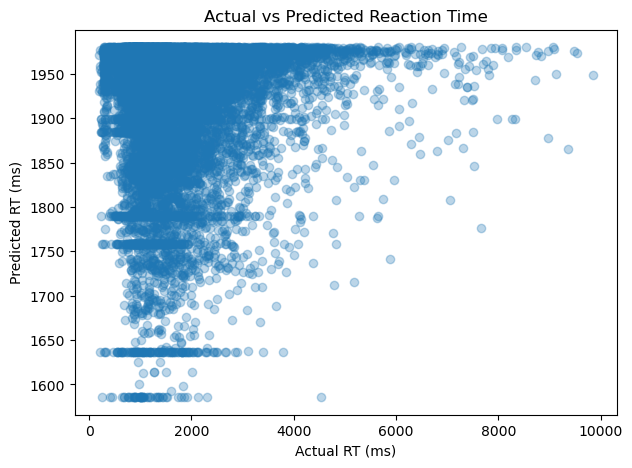

In [22]:
plt.figure(figsize=(7, 5))

plt.scatter(y_true, y_pred, alpha=0.3)

plt.xlabel("Actual RT (ms)")
plt.ylabel("Predicted RT (ms)")
plt.title("Actual vs Predicted Reaction Time")

plt.show()

## 7. Parameter Recovery

To assess whether the model parameters can be recovered, synthetic RT data are generated from known parameter values. The model is then fitted to the simulated data and the recovered parameters are compared with the known generating values.

In [23]:
def simulate_exponential_rt(value_difference, a, b, c, sigma, random_state=42):
    rng = np.random.default_rng(random_state)

    mean_rt = predict_rt_exponential(value_difference, a, b, c)

    simulated_rt = rng.normal(mean_rt, sigma)

    return simulated_rt

In [24]:
true_params = {
    "a": 1000.0,
    "b": 1200.0,
    "c": 0.01,
    "sigma": 400.0
}

print("True parameters:")
for name, value in true_params.items():
    print(f"{name}: {value}")

True parameters:
a: 1000.0
b: 1200.0
c: 0.01
sigma: 400.0


In [25]:
recovery_data = train_model_data[["value_difference"]].copy()

recovery_data["RT"] = simulate_exponential_rt(
    recovery_data["value_difference"].to_numpy(),
    true_params["a"],
    true_params["b"],
    true_params["c"],
    true_params["sigma"]
)

print(recovery_data.head())

   value_difference           RT
0         -0.004286  2321.835404
1         -2.297692  1756.748401
2         -5.179462  2439.609106
3         17.397143  2384.610974
4         25.405789  1150.362198


In [26]:
recovery_result = fit_exponential_rt_model(recovery_data)

recovered_a, recovered_b, recovered_c, recovered_sigma = (recovery_result.x)

print("Recovered parameters:")
print(f"a     = {recovered_a:.4f}")
print(f"b     = {recovered_b:.4f}")
print(f"c     = {recovered_c:.6f}")
print(f"sigma = {recovered_sigma:.4f}")

Recovered parameters:
a     = 1000.0005
b     = 1000.0004
c     = 0.003688
sigma = 499.9997


In [27]:
recovery_results = pd.DataFrame({
    "Parameter": [
        "a",
        "b",
        "c",
        "sigma"],
    "True": [
        true_params["a"],
        true_params["b"],
        true_params["c"],
        true_params["sigma"]],
    "Recovered": [
        recovered_a,
        recovered_b,
        recovered_c,
        recovered_sigma]})

recovery_results

,Parameter,True,Recovered
0,a,1000.00,1000.000460
1,b,1200.00,1000.000430
2,c,0.01,0.003688
3,sigma,400.00,499.999714


### 8. Predicted RT vs Subjective Value Difference

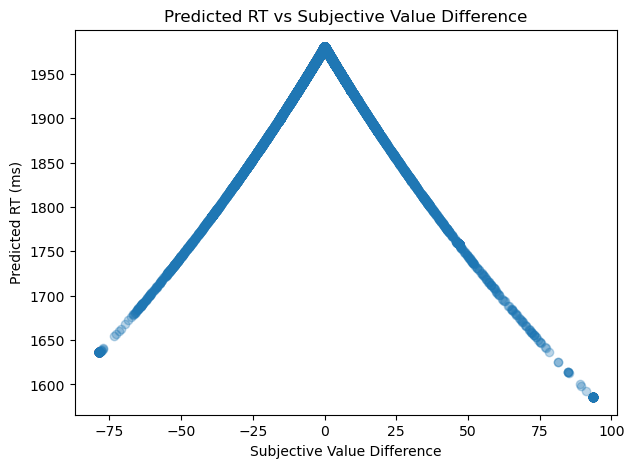

In [28]:
plt.figure(figsize=(7, 5))

plt.scatter(
    evaluation["value_difference"],
    evaluation["predicted_RT"],
    alpha=0.3
)

plt.xlabel("Subjective Value Difference")
plt.ylabel("Predicted RT (ms)")
plt.title("Predicted RT vs Subjective Value Difference")

plt.show()

### 9. Psychological Hypothesis

The Exponential Indifference Model assumes that decisions are more difficult
when the subjective values of the two options are similar. Therefore, reaction
times are expected to be longest near subjective indifference
(\(|\Delta SV| \approx 0\)) and to decrease as the subjective value difference
increases, because larger value differences make the preferred option easier
to distinguish.

## 10. Summary

The Exponential Indifference Model was used to model reaction time as a
function of the absolute difference in subjective value between the
immediate and delayed options.

The model assumes a Gaussian RT likelihood and was fitted using maximum
likelihood on the training data. The fitted model was then evaluated on
held-out test data using MAE, RMSE, and R² and compared with a mean-RT
baseline.

Parameter recovery was also evaluated by generating synthetic reaction
times from known parameter values and fitting the model to the simulated
data.

This notebook provides the implementation and individual evaluation of the
Exponential Indifference RT model. Comparison with the other RT models is
performed separately in the team-level RT model comparison analysis.